In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [36]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [37]:
df_lim = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

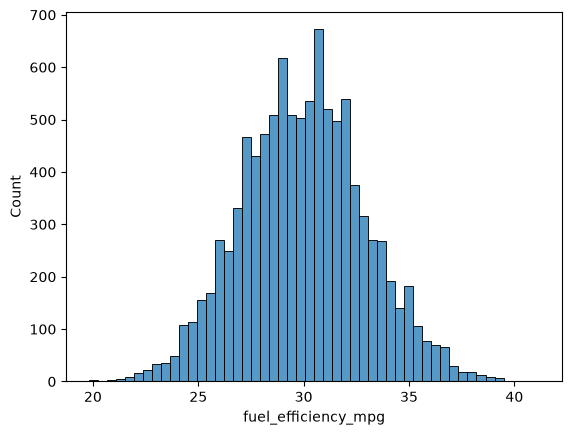

In [38]:
#It's normal distribution!
sns.histplot(df_lim.fuel_efficiency_mpg, bins=50)

In [39]:
#horsepower
df_lim.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  10000 non-null  int64  
 1   horsepower           9123 non-null   float64
 2   vehicle_weight       10000 non-null  int64  
 3   model_year           10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


In [9]:
df_lim.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [10]:
#median 254
df_lim.horsepower.median()

np.float64(254.0)

In [40]:
# Here, we randomly (seed 42) divide dataset to 60% training, 20% validation and 20% test.
def split_dataset (df, y_col, rnd_no):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(rnd_no)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    y_train = np.log1p(df_train[y_col].values)
    y_val = np.log1p(df_val[y_col].values)
    y_test = np.log1p(df_test[y_col].values)

    del df_train[y_col]
    del df_val[y_col]
    del df_test[y_col]

    return df_train, df_val, df_test, y_train, y_val, y_test

In [41]:
def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res

In [42]:
def linear_regression(X):
    return X.dot(w_new)

In [43]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [98]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [74]:
def prepare_X(df, y_col, val_empty):
    df_num = df.copy()
    df_num[y_col] = df_num[y_col].fillna(val_empty)

    return df_num

In [86]:
def predict_using_linear_regression(df_train, y_col, val_empty):
    X_train = prepare_X(df_train, y_col, val_empty).values
    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_train.dot(w)
    
    return y_pred

In [47]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [115]:
df_train, df_val, df_test, y_train, y_val, y_test = split_dataset(df_lim, 'fuel_efficiency_mpg', 42)

In [107]:
#1st attemp results with nan. Problem: Null values on horsepower
y_pred_nan = predict_using_linear_regression(df_train, 'horsepower', np.nan)
y_pred_nan

array([nan, nan, nan, ..., nan, nan, nan], shape=(6000,))

0.07127079986896065


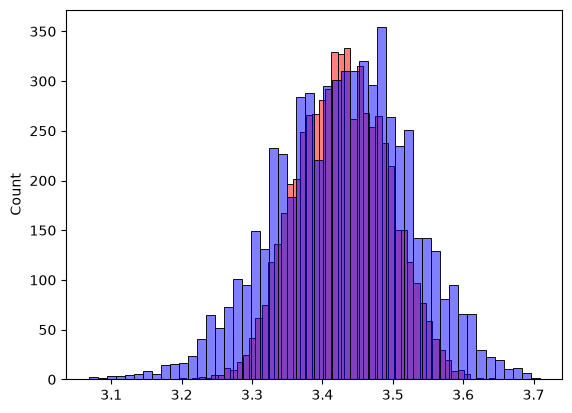

In [120]:
#2nd attempt: Fill null with 0. Result: Good ones
y_pred_0 = predict_using_linear_regression(df_train,'horsepower', 0)
sns.histplot(y_pred_0, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)
score_zero = rmse(y_train, y_pred_0)
print(score_zero)

0.07121393746648459


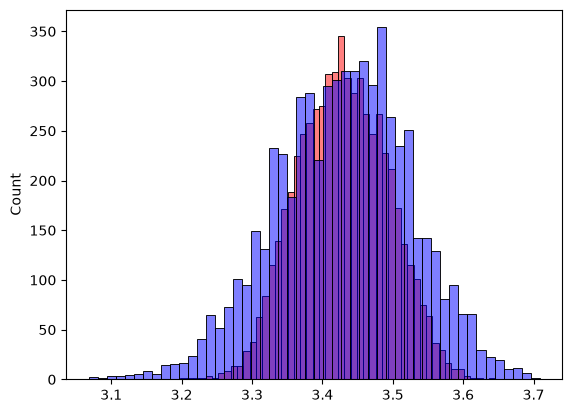

In [119]:
#3rd attempt: Fill null values with mean.
y_pred_m = predict_using_linear_regression(df_train, 'horsepower', df_train.horsepower.mean())
sns.histplot(y_pred_m, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)
score_mean = rmse(y_train, y_pred_m)
print(score_mean)

In [137]:
def find_best_regularization(df_train, col_empty, val_empty):
    X_train = prepare_X(df_train, col_empty, val_empty)
    score_list = []
    for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
        w0, w = train_linear_regression_reg(X_train, y_train, r)
        X_val = prepare_X(df_val, col_empty, val_empty)
        y_pred = w0 + X_val.dot(w)
        score = rmse(y_val, y_pred)
        score_list.append(round(score, 4))
        #Best is 100
        print('Regularization No: ', r,' | ', 'RMSE Score: ', round(score, 4))

    return score_list

In [139]:
score_list = find_best_regularization(df_train, 'horsepower', 0)
#np.std(score_list)

Regularization No:  0  |  RMSE Score:  0.0715
Regularization No:  0.01  |  RMSE Score:  0.0715
Regularization No:  0.1  |  RMSE Score:  0.0717
Regularization No:  1  |  RMSE Score:  0.0727
Regularization No:  5  |  RMSE Score:  0.0733
Regularization No:  10  |  RMSE Score:  0.0734
Regularization No:  100  |  RMSE Score:  0.0735


In [150]:
score_list = []
for i in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_train, df_val, df_test, y_train, y_val, y_test = split_dataset(df_lim, 'fuel_efficiency_mpg', i)
    y_pred = predict_using_linear_regression(df_train, 'horsepower', 0)
    score = rmse(y_train, y_pred)
    score_list.append(score)
    #Best is 2
    print('Seed No: ', i,' | ', 'RMSE Score: ', score)

Seed No:  0  |  RMSE Score:  0.07138617183087875
Seed No:  1  |  RMSE Score:  0.07139773619189774
Seed No:  2  |  RMSE Score:  0.07215155443146658
Seed No:  3  |  RMSE Score:  0.071406666314281
Seed No:  4  |  RMSE Score:  0.07139980428041173
Seed No:  5  |  RMSE Score:  0.07101007384468101
Seed No:  6  |  RMSE Score:  0.07055875774598984
Seed No:  7  |  RMSE Score:  0.07153746188939124
Seed No:  8  |  RMSE Score:  0.07127836575658625
Seed No:  9  |  RMSE Score:  0.07133063799627608


In [149]:
np.std(score_list)

np.float64(0.0003786618111461864)

In [153]:
df_train, df_val, df_test, y_train, y_val, y_test = split_dataset(df_lim, 'fuel_efficiency_mpg', 9)
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)
X_full_train = prepare_X(df_full_train, 'horsepower', 0).values
y_full_train = np.concatenate([y_train, y_val])
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
X_test = prepare_X(df_test, 'horsepower', 0).values
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score


np.float64(0.07213088684591543)